In [1]:
import xgboost as xgb

print("XGBoost Loaded Successfully")

XGBoost Loaded Successfully


In [2]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost Trained")

NameError: name 'X_train' is not defined

In [ ]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/credit_risk_model_data.csv"
)

print(df.shape)

(44006, 28)


In [ ]:
X = df.drop("default", axis=1)
y = df["default"]

print(X.shape, y.shape)

(44006, 27) (44006,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(35204, 27) (8802, 27)


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost Trained")

XGBoost Trained


In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.7989093387866394
Precision: 0.5321428571428571
Recall   : 0.16500553709856036
F1 Score : 0.2519019442096365
ROC AUC  : 0.7149491213773793


In [ ]:
confusion_matrix(y_test, y_pred_xgb)

array([[6734,  262],
       [1508,  298]])

In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.82      0.96      0.88      6996
           1       0.53      0.17      0.25      1806

    accuracy                           0.80      8802
   macro avg       0.67      0.56      0.57      8802
weighted avg       0.76      0.80      0.75      8802



In [ ]:
import joblib

joblib.dump(
    xgb_model,
    "../models/xgboost_model.pkl"
)

['../models/xgboost_model.pkl']

In [ ]:
import os
os.listdir("../models")

['logistic_regression_model.pkl',
 'random_forest_model.pkl',
 'scaler.pkl',
 'xgboost_model.pkl']

In [ ]:
import xgboost

print(xgboost.__version__)

3.2.0


In [3]:
xgb_model.feature_importances_

NotFittedError: need to call fit or load_model beforehand

In [4]:
type(xgb_model)

xgboost.sklearn.XGBClassifier

In [5]:
import joblib

xgb_model = joblib.load(
    "../models/xgboost_model.pkl"
)

print("Model Loaded")

Model Loaded


In [6]:
xgb_model.feature_importances_

array([0.04123501, 0.02864319, 0.0343734 , 0.26525328, 0.04253311,
       0.02945818, 0.02745205, 0.04150334, 0.0233905 , 0.0490933 ,
       0.03047289, 0.02585446, 0.02987481, 0.01624492, 0.02512557,
       0.02939428, 0.01774818, 0.02944775, 0.01269227, 0.02663671,
       0.02426815, 0.03420781, 0.02671922, 0.03053168, 0.03447661,
       0.02336929, 0.        ], dtype=float32)

In [7]:
import pandas as pd

feature_names = [
    'loan_amnt',
    'annual_inc',
    'dti',
    'int_rate',
    'installment',
    'avg_fico',
    'emp_length_num',
    'home_ownership_MORTGAGE',
    'home_ownership_OWN',
    'home_ownership_RENT',
    'purpose_credit_card',
    'purpose_debt_consolidation',
    'purpose_home_improvement',
    'purpose_house',
    'purpose_major_purchase',
    'purpose_medical',
    'purpose_moving',
    'purpose_other',
    'purpose_renewable_energy',
    'purpose_small_business',
    'purpose_vacation',
    'grade_B',
    'grade_C',
    'grade_D',
    'grade_E',
    'grade_F',
    'grade_G'
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
3,int_rate,0.265253
9,home_ownership_RENT,0.049093
4,installment,0.042533
7,home_ownership_MORTGAGE,0.041503
0,loan_amnt,0.041235
24,grade_E,0.034477
2,dti,0.034373
21,grade_B,0.034208
23,grade_D,0.030532
10,purpose_credit_card,0.030473


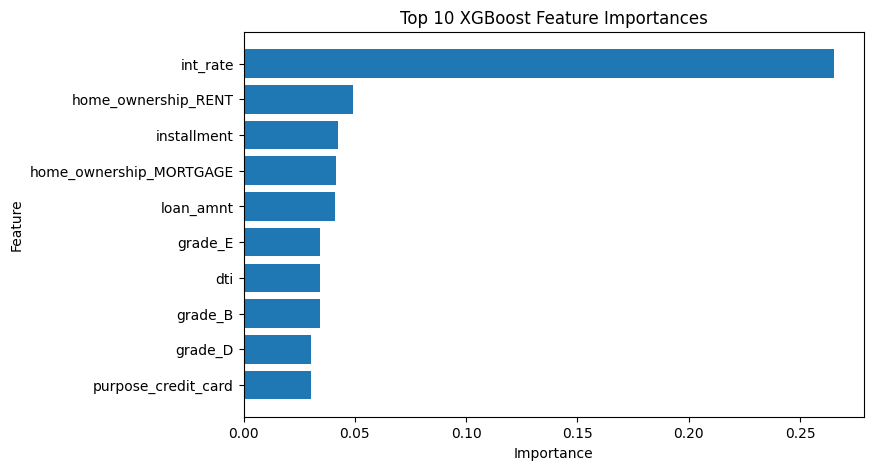

In [8]:
import matplotlib.pyplot as plt

top10 = importance_df.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost Feature Importances")

plt.gca().invert_yaxis()

plt.show()